# Explore from first principles daily reforecast of financial time series group question

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
import matplotlib.pylab as plt

## Get all questions

In [3]:
from get_market_pulse_25q3_questions import get_market_pulse_25q3_questions
ifps = get_market_pulse_25q3_questions()

200


In [4]:
import json
if 0:
    from get_underlying_urls import get_underlying_urls
    results = get_underlying_urls(ifps)
    with open('results.json', 'w') as f:
        json.dump(results, f, indent=4)
else:
    with open('results.json', 'r') as f:
        results = json.load(f)

## Acquire question data

In [5]:
from urls_to_ticker import urls_to_ticker
from pprint import pprint
sources = []
for key, (title, urls) in results.items():
    print(title)
    sources.extend(urls_to_ticker(urls))
    pprint(urls)

What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025?
['https://en.wikipedia.org/wiki/VIX',
 'https://www.tradingview.com/symbols/CBOE-VIX/',
 'https://www.cboe.com/tradable_products/vix/vix_historical_data/']
What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods?
['https://fred.stlouisfed.org/series/BAMLH0A0HYM2']
How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025?
['https://companiesmarketcap.com/',
 'https://finance.yahoo.com/quote/NVDA/history/',
 'https://finance.yahoo.com/quote/AAPL/history/']
How much will Nvidia's stock price returns exceed Microsoft's in the following biweekly periods of Q3 2025?
['https://companiesmarketcap.com/',
 'https://finance.yahoo.com/quote/NVDA/history/',
 'https://finance.yahoo.com/quote/MSFT/history/']
How much will Crude Oil Futures total price returns exceed S&P 500 Futures's in the follo

In [6]:
sources = list(sorted(set(sources)))

In [7]:
import os, joblib
from get_data_for import get_data_for
if os.path.exists('history.joblib'):
    history = joblib.load('history.joblib')
else:
    history = {(x,y,z): get_data_for(x,y,z) for x,y,z in sources}
    joblib.dump(history, 'history.joblib');

In [8]:
group_id_to_data = {int(x): results[x] for x in results}

In [9]:
results = {int(key): value for key, value in results.items()}

In [10]:
for ifp in ifps:
    ifp['sources'] = urls_to_ticker(results[ifp['group']['id']][1])
    ifp['data'] = {x: history[x] for x in ifp['sources']}
    if 'following companies' in ifp['title']:
        company = ifp['title'].split('(')[1].split(')')[0]
        ifp['sources'] = [(x,y,z) for x,y,z in ifp['sources'] if y == company]
        ifp['data'] = {(x,y,z):w for (x,y,z),w in ifp['data'].items() if y == company}

## Get forward period start and end date

In [11]:
from get_forward_period_start_and_end_date import get_forward_period_start_and_end_date

In [ ]:
for ifp in ifps:
    ifp['period'] = get_forward_period_start_and_end_date(ifp)

In [13]:
for ifp in ifps:
    print(ifp['title'])
    print(ifp['period'] if type(ifp['period']) == str else '\n'.join(ifp['period']))
    print()

What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (July 21 - Aug 1)
2025-07-21
2025-08-01

What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (Aug 4 - Aug 15)
2025-08-04
2025-08-15

What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Jul 21 - Aug 1)
2025-07-21
2025-08-01

What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Aug 4 - Aug 15)
2025-08-04
2025-08-15

How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
2025-07-21
2025-08-01

How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15)
2025-08-04
2025-08-15

How much will Nvidia's stock price returns exceed Microsoft's in the following biweekly periods of Q3 2025? (Jul 

## Parse observable of data

In [14]:
from get_observable import get_observable
import pandas as pd
pd.set_option('display.max_colwidth', 1000)

In [15]:
from get_period_type import get_period_type

In [16]:
rows = []
for i, ifp in enumerate(ifps):
    ifp['observable'] = get_observable(ifp)
    ifp['period_type'] = get_period_type(ifp)
    rows.append((ifp['id'], ifp['observable'], ifp['period'], ifp['period_type'], ifp['title']))
df = pd.DataFrame(rows, columns = ['id', 'observable', 'forward period', 'period_type', 'title'])
df

,id,observable,forward period,period_type,title
0,37926,High,"[2025-07-21, 2025-08-01]",any day in biweekly period,"What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (July 21 - Aug 1)"
1,38212,High,"[2025-08-04, 2025-08-15]",any day in biweekly period,"What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (Aug 4 - Aug 15)"
2,37932,Close,"[2025-07-21, 2025-08-01]",last day of biweekly period,What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Jul 21 - Aug 1)
3,38213,Close,"[2025-08-04, 2025-08-15]",last day of biweekly period,What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Aug 4 - Aug 15)
4,37964,stock price Close return,"[2025-07-21, 2025-08-01]",return on last vs first day of biweekly period,How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
5,38207,stock price Close return,"[2025-08-04, 2025-08-15]",return on last vs first day of biweekly period,How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15)
6,37972,stock price Close return,"[2025-07-21, 2025-08-01]",return on last vs first day of biweekly period,How much will Nvidia's stock price returns exceed Microsoft's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
7,38208,stock price Close return,"[2025-08-04, 2025-08-15]",return on last vs first day of biweekly period,How much will Nvidia's stock price returns exceed Microsoft's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15)
8,37978,futures total price Close return,"[2025-07-21, 2025-08-01]",return on last vs first day of biweekly period,How much will Crude Oil Futures total price returns exceed S&P 500 Futures's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
9,38209,futures total price Close return,"[2025-08-04, 2025-08-15]",return on last vs first day of biweekly period,How much will Crude Oil Futures total price returns exceed S&P 500 Futures's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15)


## Compute function on observables

### High on any day in forward biweekly period from today

In [ ]:
ifp = ifps[0]
print(ifp['title'])
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data'][ifp['sources'][0]][ifp['observable']]
today = datetime.now()
start_date, end_date = [datetime.strptime(date_str, "%Y-%m-%d") for date_str in period]
lookahead = np.busday_count(today.strftime('%Y-%m-%d'), start_date.strftime('%Y-%m-%d'))
A = data.values.T[0]
biweekly = 10
rng, forecast = estimate_conditional_percentiles(A, window=biweekly, gap=lookahead, Y=A[-1], epsilon=0.5)
plt.figure(figsize=(10,6))
plt.plot(rng, forecast);
underlying = ifp['sources'][0][1]
plt.ylabel(underlying)
plt.xlabel('Percentile')
plt.title(f'Empirical CDF of maximum intraday {underlying} in a 10-day period from today');

### Close on last day of biweekly period

In [ ]:
ifp = ifps[2]
print(ifp['title'])
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data'][ifp['sources'][0]]
today = datetime.now()

print((period_type, period, observable))

start_date, end_date = [datetime.strptime(date_str, "%Y-%m-%d") for date_str in period]
lookahead = np.busday_count(today.strftime('%Y-%m-%d'), start_date.strftime('%Y-%m-%d'))
A = data.values
biweekly = 10

from estimate_conditional_percentiles_OAS import estimate_conditional_percentiles_OAS

rng, forecast = estimate_conditional_percentiles_OAS(A, window=biweekly, gap=lookahead, Y=A[-1], epsilon=0.5)
plt.figure(figsize=(12,6))
plt.plot(rng, forecast);
underlying = ifp['sources'][0][1]
plt.ylabel(underlying)
plt.xlabel('Percentile')
plt.title(f'Empirical CDF of {observable} {period_type} {underlying} in a 10-day period from today');

### period stock price return on last vs first day of biweekly period

In [130]:
ifp = ifps[4]
print(ifp['title'])
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data']
today = datetime.now()

print((period_type, period, observable))

How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
('return on last vs first day of biweekly period', ['2025-07-21', '2025-08-01'], 'stock price Close return')


In [149]:
A2 = data[('yahoo','NVDA','price')]['Close'].values

In [150]:
A1 = data[('yahoo','AAPL','price')]['Close'].values

In [151]:
A1

array([[ 29.2836628 ],
       [ 28.04513168],
       [ 28.03168869],
       ...,
       [210.16000366],
       [210.02000427],
       [210.24029541]])

In [143]:
start_date, end_date = [datetime.strptime(date_str, "%Y-%m-%d") for date_str in period]
lookahead = np.busday_count(today.strftime('%Y-%m-%d'), start_date.strftime('%Y-%m-%d'))
biweekly = 10

In [147]:
underlying = f'R_{ifp['sources'][0][1]}-R_{ifp['sources'][1][1]}'

In [148]:
underlying

'R_NVDA-R_AAPL'

In [144]:
from estimate_conditional_diff_percentiles import estimate_conditional_diff_percentiles

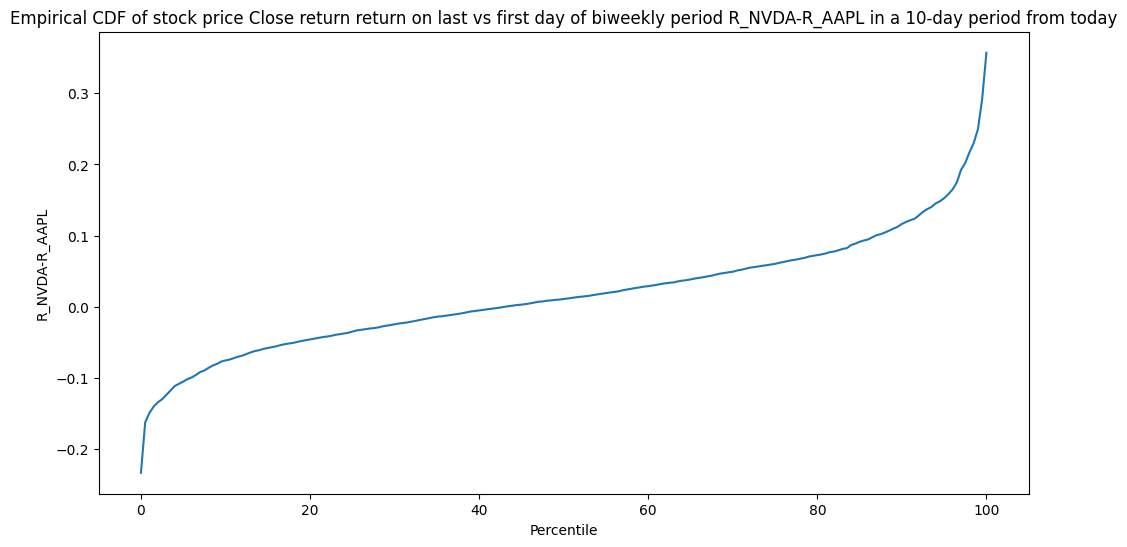

In [153]:
rng, forecast = estimate_conditional_diff_percentiles(A1, A2, window=biweekly, gap=lookahead, epsilon=0.5)
plt.figure(figsize=(12,6))
plt.plot(rng, forecast);
plt.ylabel(underlying)
plt.xlabel('Percentile')
plt.title(f'Empirical CDF of {observable} {period_type} {underlying} in a 10-day period from today');

### period futures total price return on last vs first day of biweekly period

In [ ]:
ifp = ifps[13]
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data'][ifp['sources'][0]]
title, observable, period_type, period, data 

### quarter diluted eps on next SEC filing date	

In [ ]:
ifp = ifps[16]
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data'][ifp['sources'][0]].dropna()
title, observable, period_type, period, data 

### quarter total revenue on next SEC filing date	

In [ ]:
ifp = ifps[25]
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data'][ifp['sources'][0]]
title, observable, period_type, period, data 

## Statistical model for question at hand

## Forecast the question

## Submit the question

## Repeat until all questions are forecast

## Automate and rerun

## Assess crowd alignment

In [ ]:
ifp['group']['group_of_questions'].keys()

In [ ]:
print(ifp['group']['group_of_questions']['resolution_criteria'])

In [ ]:
vix = ifp['inputs'][('yahoo', '^VIX', 'price')]

In [ ]:
ifp['title']

In [ ]:
vix['Close']['^VIX'].plot();

In [ ]:
df_vix = vix[['High']]

In [ ]:
df_vix.columns = ['^VIX']

In [ ]:
ifp['title']

In [ ]:
today = str(datetime.now())[0:10]
today

In [ ]:
future_start = '2025-07-21'
future_end = '2025-08-01'

In [ ]:
cdf_vix = conditional_future_vix_max_cdf(
    df_vix,             # DataFrame with Date index & column '^VIX'
    today,                   # Today's date as 'YYYY-MM-DD'
    future_start,            # Start of window as 'YYYY-MM-DD'
    future_end,              # End of window as 'YYYY-MM-DD'
    band=0.5                # Conditioning band in VIX units, e.g. ±0.5
)

In [ ]:
pdf_vix = cdf_to_pdf(cdf_vix)

In [ ]:
percentiles = np.arange(0,100.5,0.5)

In [ ]:
plt.plot(percentiles, pdf_vix);

In [ ]:
%matplotlib inline
import matplotlib.pylab as plt
plt.plot(percentiles, cdf_vix);